# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(541909, 8)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


## A.2. Missing values & Duplicate data

In [3]:
print(df.isna().sum())
print('Duplicates:', df.duplicated().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Duplicates: 5268


## A.3. Invalid values

In [4]:
print('Quantity <= 0:', (df.Quantity <= 0).sum())
print('UnitPrice <= 0:', (df.UnitPrice <= 0).sum())
print('InvoiceDate errors:', df.InvoiceDate.isna().sum())
print('Customers missing:', df.CustomerID.isna().sum())

Quantity <= 0: 10624
UnitPrice <= 0: 2517
InvoiceDate errors: 0
Customers missing: 135080


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [5]:
raw_df = df.copy()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
df['Sales'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
print(df[['Quantity', 'UnitPrice', 'Sales']].mean())
print(df[['Quantity', 'UnitPrice', 'Sales']].median())
print(df[['Quantity', 'UnitPrice', 'Sales']].mode().iloc[0])

Quantity     10.542037
UnitPrice     3.907625
Sales        20.121871
dtype: float64
Quantity     3.00
UnitPrice    2.08
Sales        9.90
dtype: float64
Quantity      1.00
UnitPrice     1.25
Sales        15.00
Name: 0, dtype: float64


## Group 2 — Dispersion

In [7]:
print(df[['Quantity', 'UnitPrice', 'Sales']].std())
print(df[['Quantity', 'UnitPrice', 'Sales']].min())
print(df[['Quantity', 'UnitPrice', 'Sales']].max())

Quantity     155.524124
UnitPrice     35.915681
Sales        270.356743
dtype: float64
Quantity     1.000
UnitPrice    0.001
Sales        0.001
dtype: float64
Quantity      80995.00
UnitPrice     13541.33
Sales        168469.60
dtype: float64


## Group 3 — Location and Shape

In [8]:
print(df[['Quantity', 'UnitPrice', 'Sales']].quantile([0.25, 0.5, 0.75]))
print(df[['Quantity', 'UnitPrice', 'Sales']].skew())
print(df[['Quantity', 'UnitPrice', 'Sales']].kurtosis())

      Quantity  UnitPrice  Sales
0.25       1.0       1.25   3.75
0.50       3.0       2.08   9.90
0.75      10.0       4.13  17.70
Quantity     471.727716
UnitPrice    206.087555
Sales        506.706012
dtype: float64
Quantity     236462.342826
UnitPrice     62483.142715
Sales        297651.661046
dtype: float64


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [9]:
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
print(country_sales.head())
print('Top percentage:', country_sales.iloc[0] / country_sales.sum() * 100)

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Name: Sales, dtype: float64
Top percentage: 84.61131522893568


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [10]:
print(df.groupby('Description')['Sales'].sum().sort_values(ascending=False).head(10))

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Sales, dtype: float64


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

InvoiceDate
1      691364.560
2      523631.890
3      717639.360
4      537808.621
5      770536.020
6      761739.900
7      719221.191
8      759138.380
9     1058590.172
10    1154979.300
11    1509496.330
12    1462538.820
Name: Sales, dtype: float64


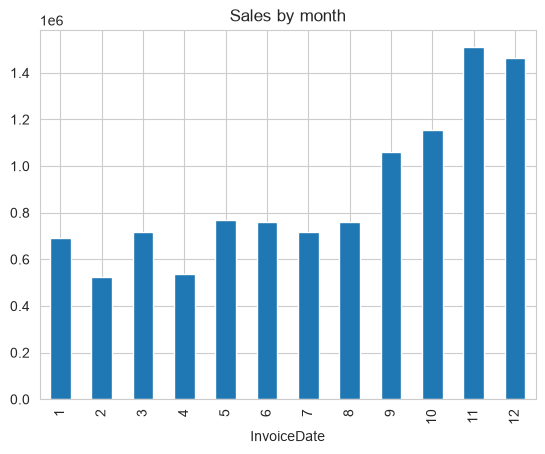

In [11]:
monthly = df.groupby(df['InvoiceDate'].dt.month)['Sales'].sum()
print(monthly)
monthly.plot(kind='bar', title='Sales by month')
plt.show()

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [12]:
orders = df.groupby(['InvoiceNo', 'Country'])['Sales'].sum()
print(orders.groupby(level='Country').mean().sort_values(ascending=False).head(10))

Country
Singapore      3039.898571
Netherlands    3036.663191
Australia      2430.198421
Japan          1969.282632
Lebanon        1693.880000
Hong Kong      1426.527273
Brazil         1143.600000
Sweden         1066.064722
Switzerland    1057.220370
Denmark        1053.074444
Name: Sales, dtype: float64


## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

In [13]:
returns = raw_df.assign(return_row=raw_df['Quantity'] < 0).groupby('Country')['return_row'].mean().sort_values(ascending=False)
print(returns.head(10))

Country
USA               0.384880
Czech Republic    0.166667
Malta             0.118110
Japan             0.103352
Saudi Arabia      0.100000
Australia         0.058777
Italy             0.056040
Bahrain           0.052632
Germany           0.047709
EIRE              0.036847
Name: return_row, dtype: float64


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Doanh thu tập trung chủ yếu ở một số quốc gia, trong đó quốc gia đứng đầu chiếm tỷ trọng lớn nhất. Một số sản phẩm tạo ra doanh thu nổi bật hơn phần còn lại. Doanh số thay đổi theo tháng, cho thấy khả năng có mùa vụ. Giá trị đơn hàng trung bình khác nhau giữa các quốc gia. Tỷ lệ dòng hàng bị trả lại cũng không đồng đều giữa các quốc gia.